# Regression - Monetary Total Prediction

Predict customer monetary value and compare regression models.


In [1]:
from pathlib import Path
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROCESSED_DATA_PATH = Path('../data/processed/retail_customers_cleaned.csv')
REPORTS_DIR = Path('../reports')
MODEL_DIR = Path('../models')
print('Environment ready')


Environment ready


In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH)
print('Processed data shape:', df.shape)
display(df.head())


Processed data shape: (4372, 56)


,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,...,Churn,RegYear,RegMonth,RegDay,RegWeekday,IP_FirstOctet,IP_IsPrivate,MonetaryPerDay,AvgBasketValue,TenureRatio
0,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,...,1,2010,7,17,5,59,0,17.454224,146.906389,4.194444
1,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,...,0,2010,10,4,0,77,0,93.306061,162.057895,0.093294
2,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,...,0,2009,9,12,5,51,0,1796.835000,378.281053,0.008086
3,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,...,1,2010,1,28,3,10,1,9.775773,158.041667,0.344086
4,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,...,1,2009,12,10,3,186,0,1.918731,90.728571,7.500000


In [3]:
target = 'MonetaryTotal'
leakage_cols = ['Churn', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'MonetaryPerDay', 'AvgBasketValue']
X = df.drop(columns=[target])
y = df[target]
X = X.drop(columns=leakage_cols, errors='ignore')
print('Target:', target)
print('Feature matrix shape:', X.shape)
print('Target summary')
display(y.describe().round(2).to_frame())


Target: MonetaryTotal
Feature matrix shape: (4372, 48)
Target summary


,MonetaryTotal
count,4372.00
mean,1898.46
std,8219.35
min,-4287.63
25%,293.36
50%,648.08
75%,1611.72
max,279489.02


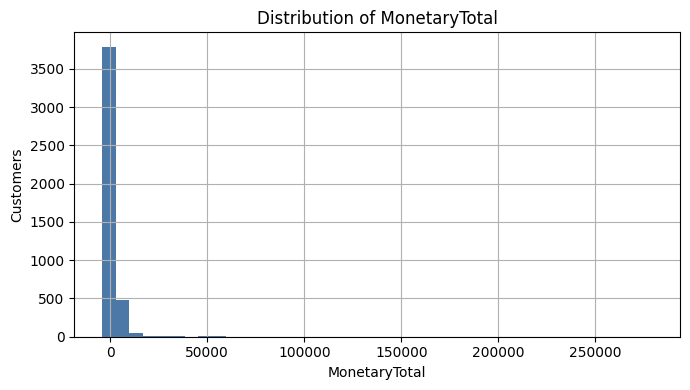

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
y.hist(ax=ax, bins=40, color='#4c78a8')
ax.set_title('Distribution of MonetaryTotal')
ax.set_xlabel('MonetaryTotal')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))


Train shape: (3497, 48) Test shape: (875, 48)
Numeric features: 34
Categorical features: 14


C:\Users\USER\AppData\Local\Temp\ipykernel_13816\2816123367.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


In [6]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])
print('Preprocessor ready')


Preprocessor ready


In [7]:
models = [
    ('Linear Regression', LinearRegression()),
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=200, random_state=42)),
]
results = []
predictions = {}
for name, model in models:
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions[name] = {'pipeline': pipeline, 'y_pred': y_pred}
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })
results_df = pd.DataFrame(results).sort_values('RMSE')
print('Regression results')
display(results_df.round(3))


Regression results


,Model,MAE,RMSE,R2
0,Linear Regression,840.507,6603.897,0.661
1,Random Forest Regressor,741.016,7342.255,0.581


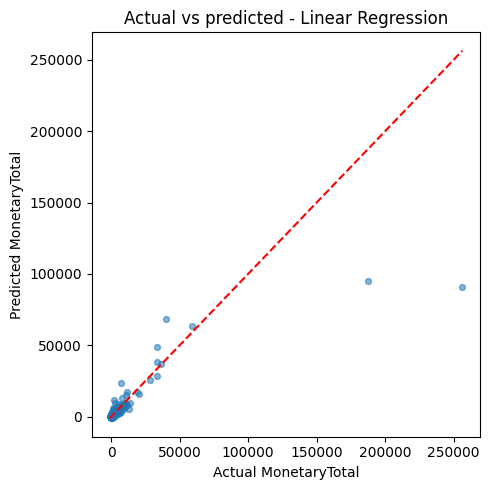

In [8]:
best_name = results_df.iloc[0]['Model']
best_pred = predictions[best_name]['y_pred']
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, best_pred, alpha=0.55, s=18)
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
ax.plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--')
ax.set_title(f'Actual vs predicted - {best_name}')
ax.set_xlabel('Actual MonetaryTotal')
ax.set_ylabel('Predicted MonetaryTotal')
plt.tight_layout()
plt.show()


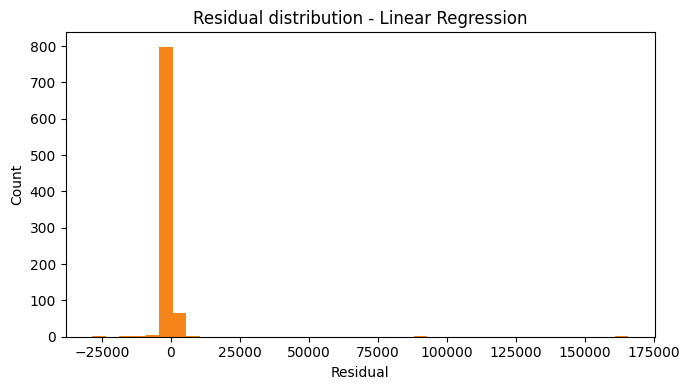

In [9]:
residuals = y_test - best_pred
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=40, color='#f58518')
ax.set_title(f'Residual distribution - {best_name}')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [10]:
saved_results = pd.read_csv(REPORTS_DIR / 'regression_results.csv').sort_values('RMSE')
print('Saved regression report')
display(saved_results.round(3))


Saved regression report


,Model,MAE,RMSE,R2
0,Linear Regression,840.507,6603.897,0.661
1,Random Forest Regressor,741.016,7342.255,0.581


In [11]:
saved_model = joblib.load(MODEL_DIR / 'best_regression_model.joblib')
print('Saved best regression model type:', type(saved_model).__name__)
print(saved_model)


Saved best regression model type: Pipeline
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Recency', 'Frequency',
                                                   'TotalQuantity',
                                                   'AvgQuantityPerTransaction',
                                                   'MinQuantity', 'MaxQuantity',
                                                   'CustomerTenureDays',
                                                   'FirstPurchaseDaysAgo',
                                                   'PreferredDayOfWeek

## Regression conclusion

The regression model estimates customer monetary value. It should be used together with churn risk to prioritize retention and loyalty actions.
